In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


#### **1. Ingesting & Partitioning the Dataset**

In [3]:
print("Executing Step 1: Fetching MNIST dataset (70,000 images)...")
# Fetch the official MNIST dataset by name from OpenML
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

X = mnist.data
y = mnist.target.astype(int) # Convert target labels from text strings to numbers

print("Executing Step 2: Segmenting data into train and test vectors...")
# To keep training fast for your assignment, we will use a subset of 10,000 rows
X_sample, _, y_sample, _ = train_test_split(X, y, train_size=10000, random_state=1, stratify=y)

# Perform our standard 80% training / 20% testing split on the sample subset
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=1)

Executing Step 1: Fetching MNIST dataset (70,000 images)...
Executing Step 2: Segmenting data into train and test vectors...



#### **2. Model Training (Logistic Regression)**

In [7]:
print("Executing Step 3: Fitting Logistic Regression (Max Iterations=1000)...")
# max_iter is restricted to 100 to ensure the assignment finishes executing quickly
classifier = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=1)
classifier.fit(X_train, y_train)

Executing Step 3: Fitting Logistic Regression (Max Iterations=1000)...


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,1
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'



#### **3. Computing Performance Metrics**

In [8]:
print("Executing Step 4: Assessing performance accuracy scores...")
train_accuracy = classifier.score(X_train, y_train)
test_accuracy = classifier.score(X_test, y_test)

print("\n" + "="*45)
print("     DIGIT CLASSIFIER ACCURACY METRICS     ")
print("="*45)
print(f"Training Subset Accuracy: {train_accuracy * 100:.2f}%")
print(f"Testing Subset Accuracy:  {test_accuracy * 100:.2f}%")
print("="*45 + "\n")


Executing Step 4: Assessing performance accuracy scores...

     DIGIT CLASSIFIER ACCURACY METRICS     
Training Subset Accuracy: 100.00%
Testing Subset Accuracy:  87.50%




#### **4. Diagnostic Prediction Extraction**


In [9]:
# Generate predictions across the unseen test set
y_pred = classifier.predict(X_test)

# Find indexes of correct and incorrect predictions
correct_indices = np.where(y_pred == y_test)[0]
incorrect_indices = np.where(y_pred != y_test)[0]

#### **5. Visualizing Predictions via Matplotlib**

Executing Step 5: Generating correct vs. incorrect visual grid...


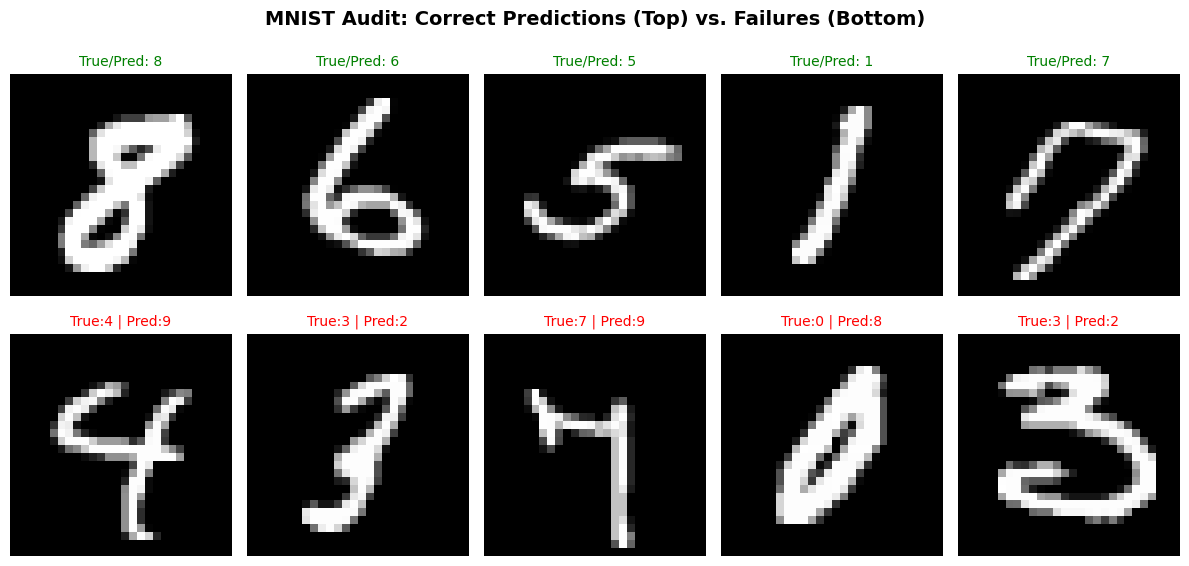

In [10]:
print("Executing Step 5: Generating correct vs. incorrect visual grid...")
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('MNIST Audit: Correct Predictions (Top) vs. Failures (Bottom)', fontsize=14, fontweight='bold')

# Plot 5 Correctly Classified Images in the Top Row
for i, idx in enumerate(correct_indices[:5]):
    ax = axes[0, i]
    # Reshape the flat 784 array back into a 28x28 square for plotting
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"True/Pred: {y_test[idx]}", color='green', fontsize=10)
    ax.axis('off')

# Plot 5 Incorrectly Classified Images in the Bottom Row
for i, idx in enumerate(incorrect_indices[:5]):
    ax = axes[1, i]
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"True:{y_test[idx]} | Pred:{y_pred[idx]}", color='red', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()